## 1 - Project Setup
This section initializes the workspace, mounts Google Drive (on Colab) or resolves local VM
paths, extracts the dataset, and authenticates with HuggingFace Hub.

**Note:** DINOv3 checkpoints on HuggingFace are gated. You need to accept the license at
https://huggingface.co/facebook/dinov3-vits16-pretrain-lvd1689m and have an access token
with read permission before running the login cell below.

In [1]:
%pip install -q transformers huggingface_hub accelerate

import os
import glob
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from huggingface_hub import login
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import AutoModel
from tqdm.auto import tqdm
import random
import gc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
# Environment setup: works both on Colab (Drive-mounted) and on a local VM/JupyterLab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/internship-deepfake-forensic'
    DATASET_DIR = '/content/dataset'
    MODELS_DIR = os.path.join(DRIVE_ROOT, 'deepfake_models_final')

    if not os.path.exists(DATASET_DIR):
        print("Extracting the dataset... (this might take a few minutes)")
        !unzip -q {os.path.join(DRIVE_ROOT, 'deepfake_dataset.zip')} -d {DATASET_DIR}
        print("Extraction completed!")
    else:
        print("Dataset already present and ready to use!")
else:
    DATA_ROOT = '/home/lucia_pola/internship-deepfake-forensic/deepfake-forensics-pipeline/02_Extended_Framework'
    DATASET_DIR = os.path.join(DATA_ROOT, 'Datasets')
    MODELS_DIR = os.path.join(DATA_ROOT, 'deepfake_models_final')
    print(f"Running outside Colab. Using local paths under: {DATA_ROOT}")

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Dataset directory: {DATASET_DIR}")
print(f"Models directory:  {MODELS_DIR}")

Mounted at /content/drive
Extracting the dataset... (this might take a few minutes)
Extraction completed!
Dataset directory: /content/dataset
Models directory:  /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final


In [3]:
# Log in to HuggingFace Hub to access the gated DINOv3 checkpoints
login()

## 2 - Dataset and Augmentation Baseline

In [4]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dirs, fake_dirs, transform=None):
        self.filepaths, self.labels = [], []
        self.transform = transform
        extensions = ('*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG')
        for d in real_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([0] * len(paths))
        for d in fake_dirs:
            for ext in extensions:
                paths = sorted(glob.glob(os.path.join(d, ext)))
                self.filepaths.extend(paths)
                self.labels.extend([1] * len(paths))

    def __len__(self): return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor([self.labels[idx]], dtype=torch.float32)

class RandomJpegCompression:
    """
    Applies a single random JPEG compression.
    """
    def __init__(self, min_quality=50, max_quality=90, p=0.5):
        self.min_quality = min_quality
        self.max_quality = max_quality
        self.p = p

    def __call__(self, img):
        if torch.rand(1).item() > self.p:
            return img

        quality = torch.randint(self.min_quality, self.max_quality + 1, (1,)).item()
        buffer = io.BytesIO()
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")

# BASELINE AUGMENTATION
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    RandomJpegCompression(min_quality=60, max_quality=95, p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Fail-safe resize
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 3 - Model Architecture (Hybrid EfficientNet-B0 + DINOv3 ViT-Small)

This notebook trains **two** dual-branch models side by side, under identical data/training
conditions and with the **same cross-attention fusion stack**, so the only variable between
them is the CNN branch design:

- **Hybrid + DINO** (`HybridDinoViTClassifier`, Proposta Finale): Hybrid EfficientNet-B0 (with
  self-attention gating) + DINOv3 ViT-Small (frozen), cross-attention fusion.
- **CNN + DINO** (`DualBranchDinoViTClassifier`): plain EfficientNet-B0 (no gating) +
  DINOv3 ViT-Small (frozen), fused with the identical cross-attention stack. This isolates
  what the CNN's self-attention gating alone contributes.

In [5]:
class CrossAttentionBlock(nn.Module):
    """
    One LSFA-style fusion round: query = DINOv3 tokens, key/value = CNN tokens.
    Residual cross-attention followed by a residual feed-forward block (standard
    transformer block, but with cross- instead of self-attention).
    """
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ffn = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, query_tokens, kv_tokens):
        q = self.norm_q(query_tokens)
        kv = self.norm_kv(kv_tokens)
        attn_out, _ = self.cross_attn(q, kv, kv)
        query_tokens = query_tokens + attn_out
        query_tokens = query_tokens + self.ffn(self.norm_ffn(query_tokens))
        return query_tokens


class HybridDinoViTClassifier(nn.Module):
    """
    Hybrid EfficientNet-B0 (trainable, self-attention gated) + DINOv3 ViT-Small (frozen),
    fused via a stack of cross-attention blocks (DINOv3 tokens as query, CNN tokens as
    key/value). Following DBCF/LGSFNet/SemDINO, the DINOv3 backbone is kept fully frozen.
    """
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()

        # --- CNN branch: EfficientNet-B0 + channel/spatial self-attention gating (trainable) ---
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280
        self.cnn_attention = nn.Sequential(
            nn.Conv2d(cnn_channels, cnn_channels // 8, 1, bias=False),
            nn.BatchNorm2d(cnn_channels // 8), nn.ReLU(inplace=True),
            nn.Conv2d(cnn_channels // 8, cnn_channels, 1, bias=False), nn.Sigmoid()
        )

        # --- DINOv3 ViT-Small branch (frozen foundation model) ---
        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        # Project CNN tokens into DINOv3's embedding space for cross-attention
        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)

        # --- Cross-attention fusion stack (trainable) ---
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])

        # --- Classification head ---
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def train(self, mode=True):
        # Keep the frozen DINOv3 backbone in eval mode even when the wrapper is set to train()
        super().train(mode)
        self.dino_backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        # The frozen DINOv3 backbone never changes: skip it so checkpoints stay small
        # and fast to write to Drive.
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        # dino_backbone.* keys are intentionally absent from our checkpoints (see
        # state_dict above); the live model already has those frozen pretrained
        # weights from AutoModel.from_pretrained, so strict=False is expected here.
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        # CNN branch (trainable)
        cnn_features = self.cnn_backbone(x)                        # [B, 1280, H, W]
        cnn_features = cnn_features * self.cnn_attention(cnn_features)
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)       # [B, H*W, 1280]
        cnn_tokens = self.cnn_proj(cnn_tokens)                     # [B, H*W, dino_dim]

        # DINOv3 branch (frozen)
        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        # Cross-attention fusion: DINOv3 tokens (query) attend to CNN tokens (key/value)
        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)

In [6]:
class DualBranchDinoViTClassifier(nn.Module):
    """
    CNN + DINOv3 ViT-Small: plain EfficientNet-B0 (trainable, NO self-attention gating) +
    DINOv3 ViT-Small (frozen), fused via the same LSFA-style cross-attention stack used by
    the Proposta Finale (chosen per the DBCF/LGSFNet/SemDINO ablations, which show naive
    concatenation underperforms cross-attention fusion). This model and
    HybridDinoViTClassifier differ ONLY in the CNN branch (plain vs self-attention-gated),
    so the fusion mechanism is held constant and the comparison isolates the CNN gating's
    contribution.
    """
    def __init__(self, num_classes=1, dino_model_id="facebook/dinov3-vits16-pretrain-lvd1689m",
                 num_fusion_blocks=3, num_heads=4):
        super().__init__()

        # --- CNN branch: plain EfficientNet-B0, no attention gating (trainable) ---
        self.cnn_backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features
        cnn_channels = 1280

        # --- DINOv3 ViT-Small branch (frozen foundation model) ---
        self.dino_backbone = AutoModel.from_pretrained(dino_model_id)
        for p in self.dino_backbone.parameters():
            p.requires_grad = False
        dino_dim = self.dino_backbone.config.hidden_size

        # Project CNN tokens into DINOv3's embedding space for cross-attention
        self.cnn_proj = nn.Linear(cnn_channels, dino_dim)

        # --- Cross-attention fusion stack (trainable) -- identical to the Proposta Finale ---
        self.fusion_blocks = nn.ModuleList([
            CrossAttentionBlock(dino_dim, num_heads=num_heads) for _ in range(num_fusion_blocks)
        ])

        # --- Classification head ---
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(dino_dim, 256), nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes)
        )

    def train(self, mode=True):
        super().train(mode)
        self.dino_backbone.eval()
        return self

    def state_dict(self, *args, **kwargs):
        full = super().state_dict(*args, **kwargs)
        return {k: v for k, v in full.items() if not k.startswith('dino_backbone.')}

    def load_state_dict(self, state_dict, *args, **kwargs):
        return super().load_state_dict(state_dict, *args, strict=False, **kwargs)

    def forward(self, x):
        # CNN branch (trainable, no gating)
        cnn_features = self.cnn_backbone(x)                        # [B, 1280, H, W]
        B, C, H, W = cnn_features.shape
        cnn_tokens = cnn_features.flatten(2).transpose(1, 2)       # [B, H*W, 1280]
        cnn_tokens = self.cnn_proj(cnn_tokens)                     # [B, H*W, dino_dim]

        # DINOv3 branch (frozen)
        with torch.no_grad():
            dino_out = self.dino_backbone(pixel_values=x)
            dino_tokens = getattr(dino_out, "last_hidden_state", None)
            if dino_tokens is None:
                dino_tokens = dino_out[0]

        # Cross-attention fusion: DINOv3 tokens (query) attend to CNN tokens (key/value)
        fused = dino_tokens
        for block in self.fusion_blocks:
            fused = block(fused, cnn_tokens)

        pooled = fused.mean(dim=1)
        return self.classifier(pooled)

In [7]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, total - trainable

for name, cls in [
    ("Modello 6: Dual-Branch, proposta finale (CNN gated + DINOv3 ViT-S)", HybridDinoViTClassifier),
    ("Modello 5: Dual-Branch, ablazione (CNN + DINOv3 ViT-S)", DualBranchDinoViTClassifier),
]:
    m = cls()
    total, trainable, frozen = count_params(m)
    print(f"[{name}]")
    print(f"  Totali:       {total:,}")
    print(f"  Addestrabili: {trainable:,}")
    print(f"  Congelati:    {frozen:,}\n")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 107MB/s] 


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 86.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[Modello 6: Dual-Branch, proposta finale (CNN gated + DINOv3 ViT-S)]
  Totali:       31,930,429
  Addestrabili: 10,333,885
  Congelati:    21,596,544



Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[Modello 5: Dual-Branch, ablazione (CNN + DINOv3 ViT-S)]
  Totali:       31,520,509
  Addestrabili: 9,923,965
  Congelati:    21,596,544



## 4 - Training Engine

In [8]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0.001, path='best_model.pth'):
        self.patience, self.delta, self.path = patience, delta, path
        self.counter, self.best_score, self.early_stop = 0, None, False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    #ModelCheckPoint - save the model when improve
    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_and_validate(model, train_loader, val_loader, epochs, optimizer, criterion, device, early_stopper, scheduler=None):
    scaler = torch.amp.GradScaler('cuda')

    history = {
        'epoch': [],
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", unit="batch", leave=False)

        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * images.size(0)

            predicted = (outputs > 0.0).float()
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_bar.set_postfix(loss=loss.item(), acc=train_correct/train_total)

        # VALIDATION PHASE
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", unit="batch", leave=False)

        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predicted = (outputs > 0.0).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / train_total
        avg_val_loss = val_loss / val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        print(f"END EPOCH {epoch+1} -> Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f}")

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        # SCHEDULER LOGIC
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(avg_val_loss)
            else:
                scheduler.step()

        early_stopper(avg_val_loss, model)
        if early_stopper.early_stop:
            print(">> Early stopping activate!")
            break
        print("-" * 30)

    history_path = early_stopper.path.replace('.pth', '_history.csv')
    pd.DataFrame(history).to_csv(history_path, index=False)
    print(f"Training history saved successfully in: {history_path}")

    return history

def load_or_train(model, model_path, train_loader, val_loader, epochs, optimizer, criterion, device, early_stopper, scheduler=None):
    history = None
    if os.path.exists(model_path):
        print(f"Model found! Skipping training and loading weights from:\n{model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))

        history_path = model_path.replace('.pth', '_history.csv')
        if os.path.exists(history_path):
            history = pd.read_csv(history_path).to_dict(orient='list')
            print(f"Training history loaded from: {history_path}")
    else:
        print(f"Model not found. Starting the training procedure...")
        history = train_and_validate(
            model, train_loader, val_loader, epochs, optimizer,
            criterion, device, early_stopper, scheduler
        )
        # Load the best model saved by EarlyStopping at the end of training
        model.load_state_dict(torch.load(model_path, map_location=device))

    return history

## 5 - Data Configuration

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

path_intra = os.path.join(MODELS_DIR, 'baseline_hybriddino', 'path')
os.makedirs(path_intra, exist_ok=True)
print(f"In this step the Proposta Finale model is saved in: {path_intra}")

path_intra_dual = os.path.join(MODELS_DIR, 'baseline_dualdino', 'path')
os.makedirs(path_intra_dual, exist_ok=True)
print(f"In this step the CNN + DINO model is saved in: {path_intra_dual}")

BATCH_SIZE = 32
MAX_EPOCHS = 15
NUM_WORKERS = 4

# SETUP
tr_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/train/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/train/original/']
tr_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/train/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/train/fake/']
vl_reals = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/val/original/', f'{DATASET_DIR}/CELEBDFV3_DATASET/val/original/']
vl_fakes = [f'{DATASET_DIR}/FEI_MORPHV2_DATASET/val/fake/', f'{DATASET_DIR}/CELEBDFV3_DATASET/val/fake/']

train_ds = DeepfakeDataset(tr_reals, tr_fakes, train_transforms)
val_ds = DeepfakeDataset(vl_reals, vl_fakes, val_test_transforms)

def get_criterion_from_labels(labels):
    num_reals = labels.count(0)
    num_fakes = labels.count(1)
    balance_ratio = num_reals / num_fakes if num_fakes > 0 else 1.0
    print(f"Class balance computed: {num_reals} Real / {num_fakes} Fake (pos_weight: {balance_ratio:.4f})")
    return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([balance_ratio]).to(device))

print("\nComputing class weights:")
criterion = get_criterion_from_labels(train_ds.labels)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=NUM_WORKERS, persistent_workers=True)

Device in use: cuda
In this step the Proposta Finale model is saved in: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_hybriddino/path
In this step the CNN + DINO model is saved in: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_dualdino/path

Computing class weights:
Class balance computed: 1700 Real / 96983 Fake (pos_weight: 0.0175)


## 6 - Training Phase

In [10]:
#HYBRID EFFICIENTNET-B0 + DINOV3 VIT-SMALL (PROPOSTA FINALE)
model_hybrid_dino = HybridDinoViTClassifier().to(device)

# Only the CNN branch + fusion stack + classifier are trainable (DINOv3 backbone is frozen)
trainable_params = [p for p in model_hybrid_dino.parameters() if p.requires_grad]
optimizer_hd = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-5)
scheduler_hd = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_hd, mode='min', factor=0.5, patience=2
)
path_hybrid_dino = os.path.join(path_intra, "hybrid_dinovit_step1.pth")
early_stopper_hd = EarlyStopping(patience=10, path=path_hybrid_dino)

print("--- HYBRID EFFICIENTNET-B0 + DINOV3 VIT-SMALL --> START TRAINING ---")
load_or_train(
    model_hybrid_dino,
    path_hybrid_dino,
    train_loader,
    val_loader,
    MAX_EPOCHS,
    optimizer_hd,
    criterion,
    device,
    early_stopper_hd,
    scheduler_hd
)

# Free GPU memory
del model_hybrid_dino, optimizer_hd, scheduler_hd
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

--- HYBRID EFFICIENTNET-B0 + DINOV3 VIT-SMALL --> START TRAINING ---
Model not found. Starting the training procedure...


Epoch 1/15 [Train]:   0%|          | 0/3084 [00:00<?, ?batch/s]

Epoch 1/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 1 -> Train Loss: 0.0185, Acc: 0.7111 | Val Loss: 0.0132, Acc: 0.9111
------------------------------


...

Epoch 14/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 14 -> Train Loss: 0.0039, Acc: 0.9423 | Val Loss: 0.0170, Acc: 0.9538
------------------------------


Epoch 15/15 [Train]:   0%|          | 0/3084 [00:00<?, ?batch/s]

Epoch 15/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 15 -> Train Loss: 0.0038, Acc: 0.9463 | Val Loss: 0.0211, Acc: 0.9638
------------------------------
Training history saved successfully in: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_hybriddino/path/hybrid_dinovit_step1_history.csv


In [11]:
#CNN + DINOV3 VIT-SMALL: EFFICIENTNET-B0 (PLAIN) + DINOV3 VIT-SMALL (CROSS-ATTENTION)
model_dual_dino = DualBranchDinoViTClassifier().to(device)

# Only the CNN branch + classifier are trainable (DINOv3 backbone is frozen)
trainable_params_dual = [p for p in model_dual_dino.parameters() if p.requires_grad]
optimizer_dd = optim.AdamW(trainable_params_dual, lr=1e-4, weight_decay=1e-5)
scheduler_dd = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_dd, mode='min', factor=0.5, patience=2
)
path_dual_dino = os.path.join(path_intra_dual, "dual_dinovit_step1.pth")
early_stopper_dd = EarlyStopping(patience=10, path=path_dual_dino)

print("--- CNN + DINOV3 VIT-SMALL (EFFICIENTNET-B0 PLAIN + CROSS-ATTENTION) --> START TRAINING ---")
load_or_train(
    model_dual_dino,
    path_dual_dino,
    train_loader,
    val_loader,
    MAX_EPOCHS,
    optimizer_dd,
    criterion,
    device,
    early_stopper_dd,
    scheduler_dd
)

# Free GPU memory
del model_dual_dino, optimizer_dd, scheduler_dd
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

--- CNN + DINOV3 VIT-SMALL (EFFICIENTNET-B0 PLAIN + CROSS-ATTENTION) --> START TRAINING ---
Model not found. Starting the training procedure...


Epoch 1/15 [Train]:   0%|          | 0/3084 [00:00<?, ?batch/s]

Epoch 1/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 1 -> Train Loss: 0.0185, Acc: 0.7177 | Val Loss: 0.0128, Acc: 0.8330
------------------------------


...

Epoch 11/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 11 -> Train Loss: 0.0042, Acc: 0.9451 | Val Loss: 0.0189, Acc: 0.9415
------------------------------


Epoch 12/15 [Train]:   0%|          | 0/3084 [00:00<?, ?batch/s]

Epoch 12/15 [Val]:   0%|          | 0/1203 [00:00<?, ?batch/s]

END EPOCH 12 -> Train Loss: 0.0037, Acc: 0.9476 | Val Loss: 0.0191, Acc: 0.9474
>> Early stopping activate!
Training history saved successfully in: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_dualdino/path/dual_dinovit_step1_history.csv


## 7 - Learning Curves Evaluation
This section generates and saves the training and validation plots (Loss and Accuracy) for both
models trained in this notebook: Hybrid + DINO (Proposta Finale) and CNN + DINO, both using the
same cross-attention fusion.

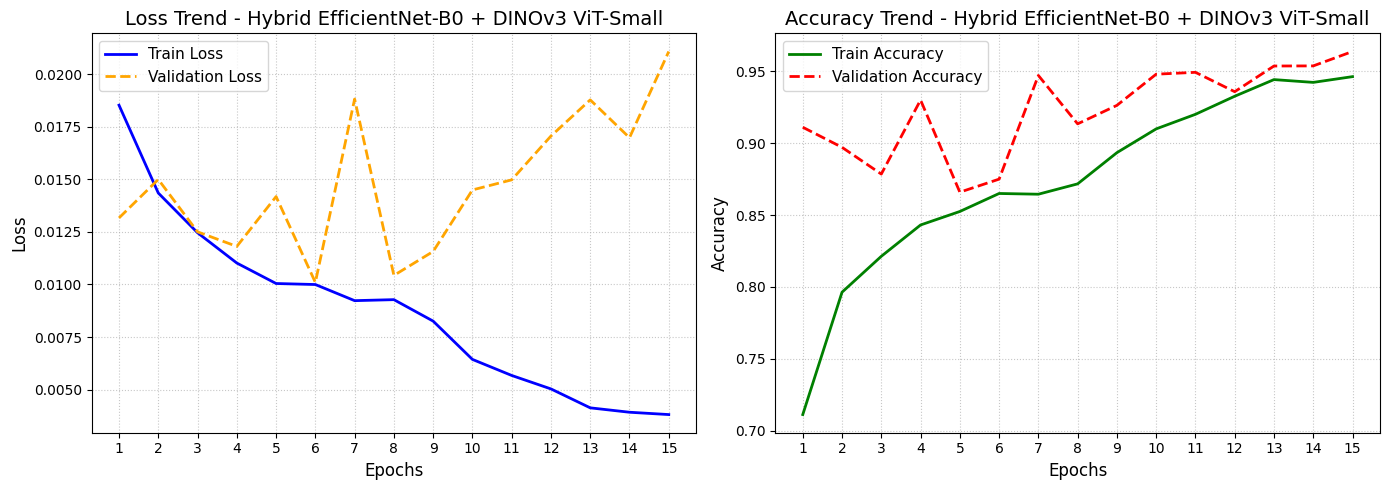

Plot successfully saved as: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_hybriddino/curves/curves_hybrid_efficientnet-b0_+_dinov3_vit-small.png


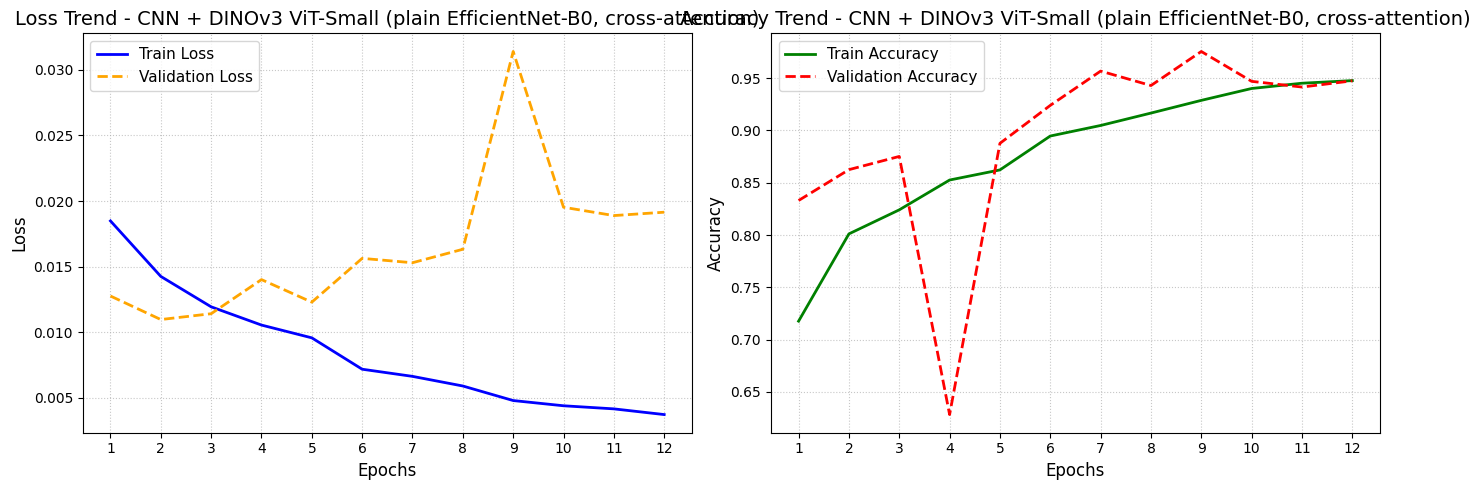

Plot successfully saved as: /content/drive/MyDrive/internship-deepfake-forensic/deepfake_models_final/baseline_dualdino/curves/curves_cnn_+_dinov3_vit-small_(plain_efficientnet-b0,_cross-attention).png


In [12]:
def plot_learning_curves(csv_path, model_name="Model", curves_path=None):
    """
    Reads the history CSV and saves an image with the Loss and Accuracy curves
    to the specified curves_path.
    """
    if curves_path is None:
        curves_path = os.path.join(MODELS_DIR, 'baseline_hybriddino', 'curves')

    if not os.path.exists(csv_path):
        print(f"Error: The file {csv_path} does not exist.")
        return

    # Load the saved data
    df = pd.read_csv(csv_path)
    epochs = df['epoch']

    plt.figure(figsize=(14, 5))

    # PLOT 1: LOSS
    plt.subplot(1, 2, 1)
    plt.plot(epochs, df['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, df['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
    plt.title(f'Loss Trend - {model_name}', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(epochs)

    # PLOT 2: ACCURACY
    plt.subplot(1, 2, 2)
    plt.plot(epochs, df['train_acc'], label='Train Accuracy', color='green', linewidth=2)
    plt.plot(epochs, df['val_acc'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
    plt.title(f'Accuracy Trend - {model_name}', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(epochs)

    plt.tight_layout()

    # Ensure the target directory exists
    os.makedirs(curves_path, exist_ok=True)

    # Generate the file name and final output path
    file_name = f"curves_{model_name.replace(' ', '_').lower()}.png"
    output_path = os.path.join(curves_path, file_name)

    # Save and display the plot
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Plot successfully saved as: {output_path}")

plot_learning_curves(os.path.join(path_intra, 'hybrid_dinovit_step1_history.csv'), model_name='Hybrid EfficientNet-B0 + DINOv3 ViT-Small')

plot_learning_curves(
    os.path.join(path_intra_dual, 'dual_dinovit_step1_history.csv'),
    model_name='CNN + DINOv3 ViT-Small (plain EfficientNet-B0, cross-attention)',
    curves_path=os.path.join(MODELS_DIR, 'baseline_dualdino', 'curves')
)
